# ETC-level analysis with etc_summary and climate indices

### Analysis ideas:
- Regress outbreak occurrence vs. climate state
- Frequency modulation (outbreak cyclone counts per teleconnection phase)
- Regress etc_summary structural predictors (min msl, deepening rate, meridional-elongation proxy) on indices to see of ENSO/MJO/SPV directly influence cyclone structure
- Compositing by index state (El Nino OC composites vs La Nina OC composites)

In [1]:
### Importing necessary packages
import pandas as pd
import os
from pathlib import Path
import re
import warnings

#warnings.filterwarnings('ignore')
import matplotlib 
import matplotlib.pyplot as plt
import matplotlib.colors as col
from matplotlib.gridspec import GridSpec
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import cmocean
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import numpy as np
import seaborn as sns
import xarray as xr
from scipy import stats


## ENSO

#### Oni index obtained from NOAA PSL

In [7]:
etc_summary = pd.read_csv('../data/etc_summary_final.csv')
oni = pd.read_csv('../data/oni_main.csv', skipfooter=8, engine='python')
oni.columns = ['time', 'ONI']

In [5]:
etc_summary

,track_id,track_start,track_end,time_min_msl,min_msl,n_steps,n_reports,n_tornado,n_hail,n_wind,n_cores_total,n_cores_kept,kept_reports,max_core_reports,time_max_reports
0,1.0,1995-12-01 00:00:00+00:00,1995-12-06 23:00:00+00:00,1995-12-02 22:00:00+00:00,980.3069,144,0,0,0,0,0,0,0,0,NaN
1,2.0,1995-12-01 00:00:00+00:00,1995-12-12 03:00:00+00:00,1995-12-10 06:00:00+00:00,961.9612,251,0,0,0,0,0,0,0,0,NaN
2,3.0,1995-12-03 06:00:00+00:00,1995-12-07 01:00:00+00:00,1995-12-05 04:00:00+00:00,994.3956,92,1,1,0,0,0,0,0,0,1995-12-06 04:00:00+00:00
3,4.0,1995-12-04 04:00:00+00:00,1995-12-06 04:00:00+00:00,1995-12-06 04:00:00+00:00,978.0338,49,0,0,0,0,0,0,0,0,NaN
4,5.0,1995-12-06 17:00:00+00:00,1995-12-08 01:00:00+00:00,1995-12-07 19:00:00+00:00,980.9462,31,0,0,0,0,0,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2220,6114.0,2025-03-24 18:00:00+00:00,2025-03-29 11:00:00+00:00,2025-03-27 22:00:00+00:00,1005.1210,106,5,0,4,1,1,0,0,0,2025-03-28 21:00:00+00:00
2221,6116.0,2025-03-26 17:00:00+00:00,2025-03-30 19:00:00+00:00,2025-03-29 10:00:00+00:00,982.2738,99,0,0,0,0,0,0,0,0,NaN
2222,6117.0,2025-03-26 22:00:00+00:00,2025-03-31 23:00:00+00:00,2025-03-31 20:00:00+00:00,992.6212,114,927,66,277,584,7,2,891,821,2025-03-30 20:00:00+00:00
2223,6119.0,2025-03-28 20:00:00+00:00,2025-03-31 21:00:00+00:00,2025-03-30 23:00:00+00:00,989.9344,73,1,0,1,0,0,0,0,0,2025-03-31 21:00:00+00:00


In [9]:
oni

,time,ONI
0,1950-01-01,-1.53
1,1950-02-01,-1.34
2,1950-03-01,-1.16
3,1950-04-01,-1.18
4,1950-05-01,-1.07
...,...,...
911,2025-12-01,-0.54
912,2026-01-01,-0.37
913,2026-02-01,-0.14
914,2026-03-01,0.13


In [10]:
etc_summary['time_min_msl'] = pd.to_datetime(etc_summary['time_min_msl'])
oni['time'] = pd.to_datetime(oni['time'])

In [11]:
etc_summary['oni_month'] = etc_summary['time_min_msl'].dt.tz_localize(None).dt.to_period('M')
oni['oni_month'] = oni['time'].dt.to_period('M')

In [12]:
etc_summary = etc_summary.merge(
    oni[['oni_month','ONI']],
    on='oni_month',
    how='left',
).drop(columns='oni_month')

In [13]:
etc_summary

,track_id,track_start,track_end,time_min_msl,min_msl,n_steps,n_reports,n_tornado,n_hail,n_wind,n_cores_total,n_cores_kept,kept_reports,max_core_reports,time_max_reports,ONI
0,1.0,1995-12-01 00:00:00+00:00,1995-12-06 23:00:00+00:00,1995-12-02 22:00:00+00:00,980.3069,144,0,0,0,0,0,0,0,0,NaN,-0.98
1,2.0,1995-12-01 00:00:00+00:00,1995-12-12 03:00:00+00:00,1995-12-10 06:00:00+00:00,961.9612,251,0,0,0,0,0,0,0,0,NaN,-0.98
2,3.0,1995-12-03 06:00:00+00:00,1995-12-07 01:00:00+00:00,1995-12-05 04:00:00+00:00,994.3956,92,1,1,0,0,0,0,0,0,1995-12-06 04:00:00+00:00,-0.98
3,4.0,1995-12-04 04:00:00+00:00,1995-12-06 04:00:00+00:00,1995-12-06 04:00:00+00:00,978.0338,49,0,0,0,0,0,0,0,0,NaN,-0.98
4,5.0,1995-12-06 17:00:00+00:00,1995-12-08 01:00:00+00:00,1995-12-07 19:00:00+00:00,980.9462,31,0,0,0,0,0,0,0,0,NaN,-0.98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2220,6114.0,2025-03-24 18:00:00+00:00,2025-03-29 11:00:00+00:00,2025-03-27 22:00:00+00:00,1005.1210,106,5,0,4,1,1,0,0,0,2025-03-28 21:00:00+00:00,-0.06
2221,6116.0,2025-03-26 17:00:00+00:00,2025-03-30 19:00:00+00:00,2025-03-29 10:00:00+00:00,982.2738,99,0,0,0,0,0,0,0,0,NaN,-0.06
2222,6117.0,2025-03-26 22:00:00+00:00,2025-03-31 23:00:00+00:00,2025-03-31 20:00:00+00:00,992.6212,114,927,66,277,584,7,2,891,821,2025-03-30 20:00:00+00:00,-0.06
2223,6119.0,2025-03-28 20:00:00+00:00,2025-03-31 21:00:00+00:00,2025-03-30 23:00:00+00:00,989.9344,73,1,0,1,0,0,0,0,0,2025-03-31 21:00:00+00:00,-0.06


In [14]:
etc_summary.to_csv('../data/etc_summary_final.csv', index=False)

## MJO:

#### Obtained from link in Tippet (2018) paper:
https://www.bom.gov.au/clim_data/IDCKGEM000/rmm.74toRealtime.txt) 

In [2]:
etc_summary = pd.read_csv('../data/etc_summary_final.csv')

In [3]:
mjo = pd.read_csv('../data/rmm.74toRealtime.txt', 
                  sep=r"\s+", 
                  skiprows=2,
                  names=["year", "month", "day","RMM1","RMM2","phase","amplitude", "method"],
                  )

In [4]:
mjo['time'] = pd.to_datetime(mjo[['year','month','day']])

In [5]:
mjo.columns

Index(['year', 'month', 'day', 'RMM1', 'RMM2', 'phase', 'amplitude', 'method',
       'time'],
      dtype='object')

In [6]:
mjo['phase']

0        5
1        5
2        5
3        5
4        5
        ..
19078    7
19079    7
19080    7
19081    7
19082    7
Name: phase, Length: 19083, dtype: int64

In [7]:
etc_summary

,track_id,track_start,track_end,time_min_msl,min_msl,n_steps,n_reports,n_tornado,n_hail,n_wind,...,RI_index_10d_min_msl,RI_index_anom_min_msl,days_since_RI_min_msl,RI_winter_max_reports,RI_index_max_reports,RI_day_max_reports,RI_day_10_max_reports,RI_index_10d_max_reports,RI_index_anom_max_reports,days_since_RI_max_reports
0,1.0,1995-12-01 00:00:00+00:00,1995-12-06 23:00:00+00:00,1995-12-02 22:00:00+00:00,980.3069,144,0,0,0,0,...,NaN,-1.709862,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,1995-12-01 00:00:00+00:00,1995-12-12 03:00:00+00:00,1995-12-10 06:00:00+00:00,961.9612,251,0,0,0,0,...,-2.308483,-1.711564,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.0,1995-12-03 06:00:00+00:00,1995-12-07 01:00:00+00:00,1995-12-05 04:00:00+00:00,994.3956,92,1,1,0,0,...,NaN,-1.877063,NaN,1996.0,-2.371725,0.0,0.0,-2.296941,-1.880178,NaN
3,4.0,1995-12-04 04:00:00+00:00,1995-12-06 04:00:00+00:00,1995-12-06 04:00:00+00:00,978.0338,49,0,0,0,0,...,-2.296941,-1.880178,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,1995-12-06 17:00:00+00:00,1995-12-08 01:00:00+00:00,1995-12-07 19:00:00+00:00,980.9462,31,0,0,0,0,...,-2.312835,-1.889243,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2220,6114.0,2025-03-24 18:00:00+00:00,2025-03-29 11:00:00+00:00,2025-03-27 22:00:00+00:00,1005.1210,106,5,0,4,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2221,6116.0,2025-03-26 17:00:00+00:00,2025-03-30 19:00:00+00:00,2025-03-29 10:00:00+00:00,982.2738,99,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2222,6117.0,2025-03-26 22:00:00+00:00,2025-03-31 23:00:00+00:00,2025-03-31 20:00:00+00:00,992.6212,114,927,66,277,584,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2223,6119.0,2025-03-28 20:00:00+00:00,2025-03-31 21:00:00+00:00,2025-03-30 23:00:00+00:00,989.9344,73,1,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# clean up RMM file and deal with missing values
# --- clean the RMM file ---
mjo['time'] = pd.to_datetime(mjo[['year', 'month', 'day']])
mjo['phase'] = pd.to_numeric(mjo['phase'], errors='coerce')
mjo['amplitude'] = pd.to_numeric(mjo['amplitude'], errors='coerce')

missing = (mjo['phase'] > 8) | (mjo['amplitude'] > 100)
mjo.loc[missing, ['phase', 'amplitude']] = np.nan

In [9]:
mjo['winter'] = mjo.time.dt.year + (mjo.time.dt.month == 12).astype(int)
mjo['dow'] = (mjo.time - pd.to_datetime((mjo.winter - 1).astype(str) + '-12-01')).dt.days

In [10]:
# mjo column: phase when amplitude is >= 1, else NA
mjo['MJO'] = mjo['phase'].where(mjo['amplitude'] >= 1).astype('Float64')

In [28]:
etc_summary['time_min_msl'] = pd.to_datetime(etc_summary['time_min_msl'], utc=True)
etc_summary['time_max_reports'] = pd.to_datetime(etc_summary['time_max_reports'], utc=True)


In [29]:
## merge on the calendar day of min msl and time max reports
etc_summary['mjo_date_min_msl'] = etc_summary['time_min_msl'].dt.tz_localize(None).dt.normalize()
etc_summary['mjo_date_max_reports'] = etc_summary['time_max_reports'].dt.tz_localize(None).dt.normalize()


In [30]:
etc_summary = etc_summary.merge(
    mjo[['time', 'MJO',]].rename(columns={
        'time': 'mjo_date_min_msl',
    }),
    on='mjo_date_min_msl',
    how='left',
).drop(columns='mjo_date_min_msl')

In [31]:
etc_summary = etc_summary.merge(
    mjo[['time', 'MJO',]].rename(columns={
        'time': 'mjo_date_max_reports',
    }),
    on='mjo_date_max_reports',
    how='left',
).drop(columns='mjo_date_max_reports')

In [32]:
etc_summary = etc_summary.rename(columns={
    'MJO_x': 'MJO_min_msl',
    'MJO_y': 'mjo_max_reports',
})

In [33]:
etc_summary

,track_id,track_start,track_end,time_min_msl,min_msl,n_steps,n_reports,n_tornado,n_hail,n_wind,n_cores_total,n_cores_kept,kept_reports,max_core_reports,time_max_reports,ONI,MJO_min_msl,mjo_max_reports
0,1.0,1995-12-01 00:00:00+00:00,1995-12-06 23:00:00+00:00,1995-12-02 22:00:00+00:00,980.3069,144,0,0,0,0,0,0,0,0,NaT,-0.98,6.0,<NA>
1,2.0,1995-12-01 00:00:00+00:00,1995-12-12 03:00:00+00:00,1995-12-10 06:00:00+00:00,961.9612,251,0,0,0,0,0,0,0,0,NaT,-0.98,7.0,<NA>
2,3.0,1995-12-03 06:00:00+00:00,1995-12-07 01:00:00+00:00,1995-12-05 04:00:00+00:00,994.3956,92,1,1,0,0,0,0,0,0,1995-12-06 04:00:00+00:00,-0.98,<NA>,7.0
3,4.0,1995-12-04 04:00:00+00:00,1995-12-06 04:00:00+00:00,1995-12-06 04:00:00+00:00,978.0338,49,0,0,0,0,0,0,0,0,NaT,-0.98,7.0,<NA>
4,5.0,1995-12-06 17:00:00+00:00,1995-12-08 01:00:00+00:00,1995-12-07 19:00:00+00:00,980.9462,31,0,0,0,0,0,0,0,0,NaT,-0.98,6.0,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2220,6114.0,2025-03-24 18:00:00+00:00,2025-03-29 11:00:00+00:00,2025-03-27 22:00:00+00:00,1005.1210,106,5,0,4,1,1,0,0,0,2025-03-28 21:00:00+00:00,-0.06,<NA>,<NA>
2221,6116.0,2025-03-26 17:00:00+00:00,2025-03-30 19:00:00+00:00,2025-03-29 10:00:00+00:00,982.2738,99,0,0,0,0,0,0,0,0,NaT,-0.06,<NA>,<NA>
2222,6117.0,2025-03-26 22:00:00+00:00,2025-03-31 23:00:00+00:00,2025-03-31 20:00:00+00:00,992.6212,114,927,66,277,584,7,2,891,821,2025-03-30 20:00:00+00:00,-0.06,<NA>,<NA>
2223,6119.0,2025-03-28 20:00:00+00:00,2025-03-31 21:00:00+00:00,2025-03-30 23:00:00+00:00,989.9344,73,1,0,1,0,0,0,0,0,2025-03-31 21:00:00+00:00,-0.06,<NA>,<NA>


In [75]:
mjo

,year,month,day,RMM1,RMM2,phase,amplitude,method,time,MJO
0,1974,6,1,1.634470,1.203040,5.0,2.029480,WH04_method:_OLR_&_NCEP_wind,1974-06-01,5.0
1,1974,6,2,1.602890,1.015120,5.0,1.897290,WH04_method:_OLR_&_NCEP_wind,1974-06-02,5.0
2,1974,6,3,1.516250,1.085510,5.0,1.864760,WH04_method:_OLR_&_NCEP_wind,1974-06-03,5.0
3,1974,6,4,1.509810,1.035730,5.0,1.830920,WH04_method:_OLR_&_NCEP_wind,1974-06-04,5.0
4,1974,6,5,1.559060,1.305180,5.0,2.033260,WH04_method:_OLR_&_NCEP_wind,1974-06-05,5.0
...,...,...,...,...,...,...,...,...,...,...
19078,2026,8,25,-0.200126,0.698792,7.0,0.726884,Gottschalk10_method:_OLR_&_ACCESS_wind,2026-08-25,<NA>
19079,2026,8,26,-0.432785,0.825932,7.0,0.932451,Gottschalk10_method:_OLR_&_ACCESS_wind,2026-08-26,<NA>
19080,2026,8,27,-0.454163,1.161678,7.0,1.247300,Gottschalk10_method:_OLR_&_ACCESS_wind,2026-08-27,7.0
19081,2026,8,28,-0.361866,0.992215,7.0,1.056143,Gottschalk10_method:_OLR_&_ACCESS_wind,2026-08-28,7.0


In [34]:
etc_summary.to_csv('../data/etc_summary_final.csv', index=False)

## SPV

In [2]:
etc_summary = pd.read_csv('../data/etc_summary_final.csv')

In [3]:
ri = xr.open_dataset(
    '/home1/lepique/circs_research/data/Reflection_index_US_ERA5_DJFM_1980-2021_12-03_center_minima_1.0_c.nc'
    )

In [36]:
ri.RI_day_10

<xarray.DataArray 'RI_day_10' (time: 121, year: 42)> Size: 20kB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(121, 42), dtype=float32)
Coordinates:
  * time     (time) int32 484B -30 -29 -28 -27 -26 -25 -24 ... 85 86 87 88 89 90
  * year     (year) int32 168B 1980 1981 1982 1983 1984 ... 2018 2019 2020 2021

In [4]:
for v in ri.data_vars:
    a = ri[v]
    print(f"{v:16s} {str(a.dims):34s} nan%={float(np.isnan(a).mean())*100:5.1f} "
          f"min={float(a.min()):8.2f} max={float(a.max()):8.2f}")

center           ('time', 'year', 'lat-lon')        nan%= 75.5 min=   59.00 max=  283.00
minimum          ('time', 'year', 'lat-lon')        nan%= 75.5 min=   48.00 max=  300.00
vT_std_canada    ('time', 'year')                   nan%=  0.0 min=   -3.66 max=    5.60
vT_std_siberia   ('time', 'year')                   nan%=  0.0 min=   -2.57 max=    4.05
vT_canada        ('time', 'year')                   nan%=  0.0 min= -130.30 max=  171.99
vT_siberia       ('time', 'year')                   nan%=  0.0 min=  -32.57 max=  179.84
RI_index         ('time', 'year')                   nan%=  0.0 min=   -5.27 max=    5.98
RI_day           ('time', 'year')                   nan%=  0.0 min=    0.00 max=    1.00
RI_day_10        ('time', 'year')                   nan%=  0.0 min=    0.00 max=    1.00


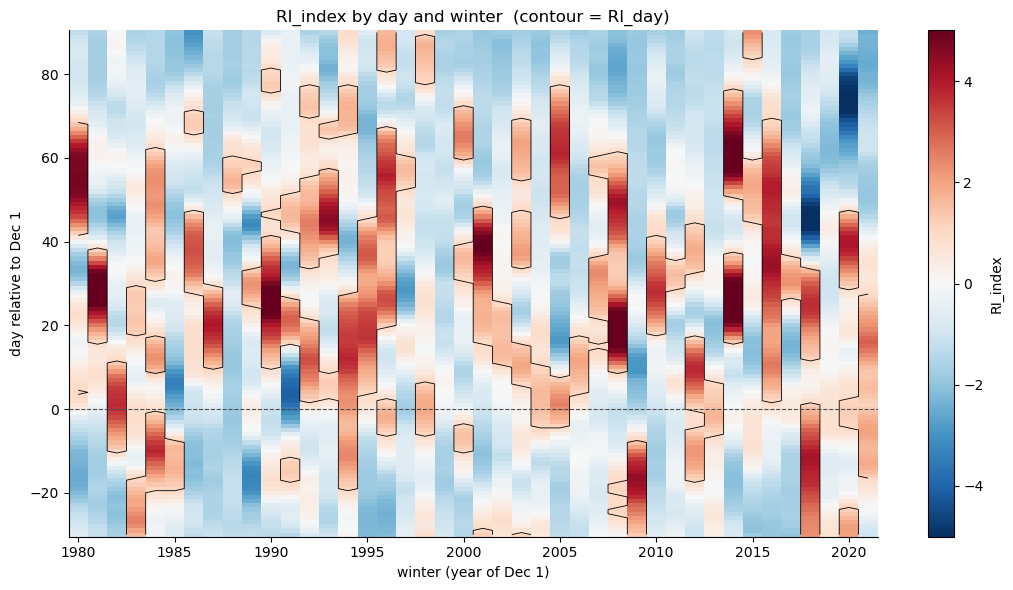

In [5]:
fig, ax = plt.subplots(figsize=(11,6))
vmax = float(abs(ri.RI_index).quantile(0.99))
m = ax.pcolormesh(ri.year, ri.time, ri.RI_index, cmap='RdBu_r',
                  vmin=-vmax, vmax=vmax, shading='nearest')
ax.contour(ri.year, ri.time, ri.RI_day, levels=[0.5], colors='k', linewidths=0.6)
ax.axhline(0, color='0.3', lw=0.8, ls='--')
ax.set_xlabel('winter (year of Dec 1)'); ax.set_ylabel('day relative to Dec 1')
ax.set_title('RI_index by day and winter  (contour = RI_day)')
fig.colorbar(m, ax=ax, label='RI_index')
for s in ('top','right'): ax.spines[s].set_visible(False)
fig.tight_layout()

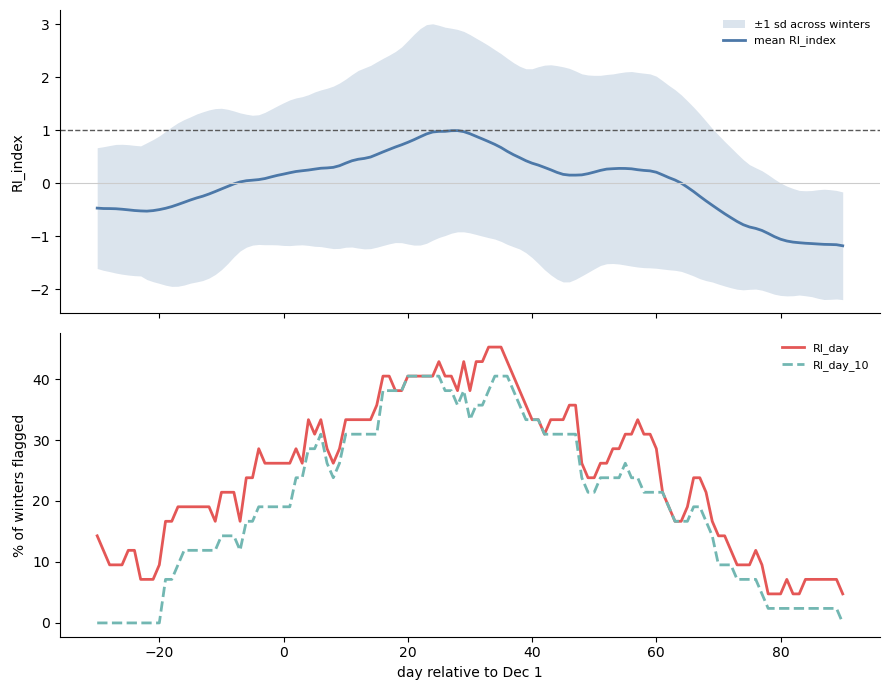

In [ ]:
fig, axes = plt.subplots(2,1, figsize=(9,7), sharex=True)
mu, sd = ri.RI_index.mean('year'), ri.RI_index.std('year')
axes[0].fill_between(ri.time, mu-sd, mu+sd, color='#4C78A8', alpha=.20, lw=0,
                     label='±1 sd across winters')
axes[0].plot(ri.time, mu, color='#4C78A8', lw=2, label='mean RI_index')
axes[0].axhline(1, color='0.35', ls='--', lw=1)
axes[0].axhline(0, color='0.8', lw=0.8)
axes[0].set_ylabel('RI_index'); axes[0].legend(frameon=False, fontsize=8)

axes[1].plot(ri.time, ri.RI_day.mean('year')*100, color='#E45756', lw=2, label='RI_day')
axes[1].plot(ri.time, ri.RI_day_10.mean('year')*100, color='#72B7B2', lw=2, ls='--',
             label='RI_day_10')
axes[1].set_ylabel('% of winters flagged'); axes[1].set_xlabel('day relative to Dec 1')
axes[1].legend(frameon=False, fontsize=8)
for ax in axes:
    for s in ('top','right'): ax.spines[s].set_visible(False)
fig.tight_layout()

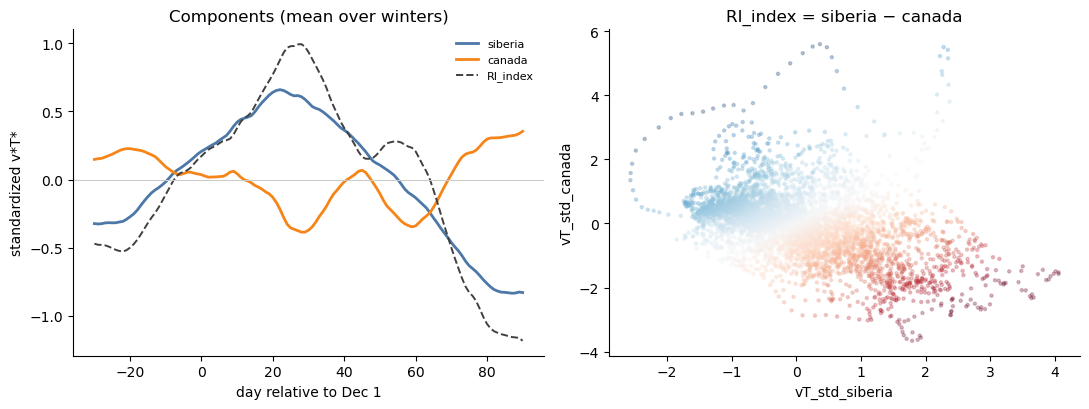

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11,4.2))
axes[0].plot(ri.time, ri.vT_std_siberia.mean('year'), color='#4C78A8', lw=2, label='siberia')
axes[0].plot(ri.time, ri.vT_std_canada.mean('year'),  color='#F58518', lw=2, label='canada')
axes[0].plot(ri.time, ri.RI_index.mean('year'), color='0.25', lw=1.4, ls='--', label='RI_index')
axes[0].axhline(0, color='0.8', lw=.8)
axes[0].set_xlabel('day relative to Dec 1'); axes[0].set_ylabel('standardized v*T*')
axes[0].set_title('Components (mean over winters)'); axes[0].legend(frameon=False, fontsize=8)

axes[1].scatter(ri.vT_std_siberia.values.ravel(), ri.vT_std_canada.values.ravel(),
                s=5, alpha=.25, c=ri.RI_index.values.ravel(),
                cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[1].set_xlabel('vT_std_siberia'); axes[1].set_ylabel('vT_std_canada')
axes[1].set_title('RI_index = siberia − canada')
for ax in axes:
    for s in ('top','right'): ax.spines[s].set_visible(False)
fig.tight_layout()

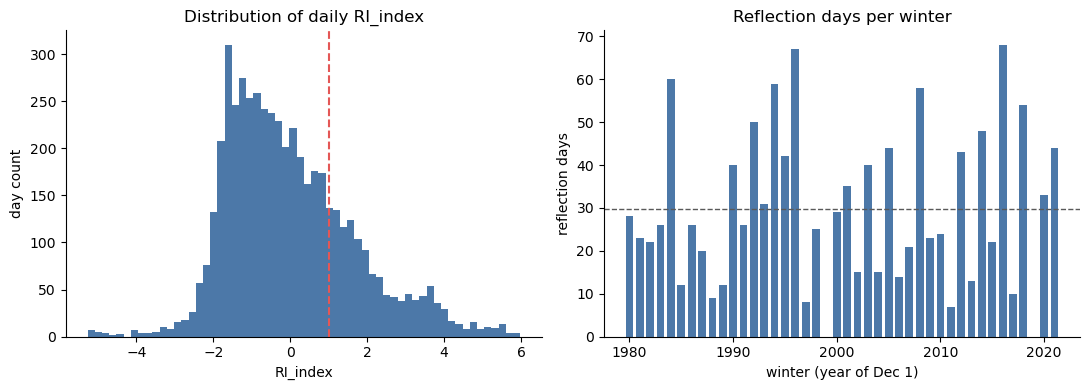

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].hist(ri.RI_index.values.ravel(), bins=60, color='#4C78A8')
axes[0].axvline(1, color='#E45756', lw=1.5, ls='--')
axes[0].set_xlabel('RI_index'); axes[0].set_ylabel('day count')
axes[0].set_title('Distribution of daily RI_index')

cnt = ri.RI_day.sum('time')
axes[1].bar(ri.year, cnt, color='#4C78A8', width=.75)
axes[1].axhline(float(cnt.mean()), color='0.35', ls='--', lw=1)
axes[1].set_xlabel('winter (year of Dec 1)'); axes[1].set_ylabel('reflection days')
axes[1].set_title('Reflection days per winter')
for ax in axes:
    for s in ('top','right'): ax.spines[s].set_visible(False)
fig.tight_layout()

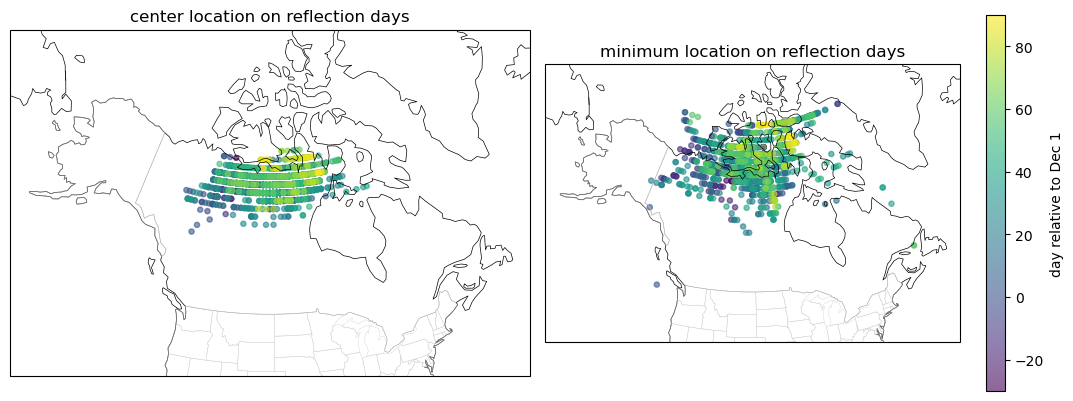

In [9]:
lat_c, lon_c = ri.center.isel({'lat-lon':0}),  ri.center.isel({'lat-lon':1})
lat_m, lon_m = ri.minimum.isel({'lat-lon':0}), ri.minimum.isel({'lat-lon':1})
day = ri.time.broadcast_like(lat_c)

fig = plt.figure(figsize=(11,5))
for i, (la, lo, name) in enumerate([(lat_c, lon_c, 'center'), (lat_m, lon_m, 'minimum')]):
    ax = fig.add_subplot(1, 2, i+1, projection=ccrs.LambertConformal(central_longitude=255))
    ax.set_extent([ri.lon.min()-5, ri.lon.max()+5, ri.lat.min()-5, ri.lat.max()+5],
                  ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, lw=.5)
    ax.add_feature(cfeature.BORDERS, lw=.4, edgecolor='0.6')
    ax.add_feature(cfeature.STATES, lw=.25, edgecolor='0.8')
    s = ax.scatter(lo.values.ravel(), la.values.ravel(), c=day.values.ravel(),
                   s=14, alpha=.6, cmap='viridis', transform=ccrs.PlateCarree())
    ax.set_title(f'{name} location on reflection days')
    if i == 1: fig.colorbar(s, ax=ax, label='day relative to Dec 1', shrink=.8)
fig.tight_layout()

In [19]:
etc_summary

,track_id,track_start,track_end,time_min_msl,min_msl,n_steps,n_reports,n_tornado,n_hail,n_wind,n_cores_total,n_cores_kept,kept_reports,max_core_reports,time_max_reports,ONI
0,1.0,1995-12-01 00:00:00+00:00,1995-12-06 23:00:00+00:00,1995-12-02 22:00:00+00:00,980.3069,144,0,0,0,0,0,0,0,0,NaN,-0.98
1,2.0,1995-12-01 00:00:00+00:00,1995-12-12 03:00:00+00:00,1995-12-10 06:00:00+00:00,961.9612,251,0,0,0,0,0,0,0,0,NaN,-0.98
2,3.0,1995-12-03 06:00:00+00:00,1995-12-07 01:00:00+00:00,1995-12-05 04:00:00+00:00,994.3956,92,1,1,0,0,0,0,0,0,1995-12-06 04:00:00+00:00,-0.98
3,4.0,1995-12-04 04:00:00+00:00,1995-12-06 04:00:00+00:00,1995-12-06 04:00:00+00:00,978.0338,49,0,0,0,0,0,0,0,0,NaN,-0.98
4,5.0,1995-12-06 17:00:00+00:00,1995-12-08 01:00:00+00:00,1995-12-07 19:00:00+00:00,980.9462,31,0,0,0,0,0,0,0,0,NaN,-0.98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2220,6114.0,2025-03-24 18:00:00+00:00,2025-03-29 11:00:00+00:00,2025-03-27 22:00:00+00:00,1005.1210,106,5,0,4,1,1,0,0,0,2025-03-28 21:00:00+00:00,-0.06
2221,6116.0,2025-03-26 17:00:00+00:00,2025-03-30 19:00:00+00:00,2025-03-29 10:00:00+00:00,982.2738,99,0,0,0,0,0,0,0,0,NaN,-0.06
2222,6117.0,2025-03-26 22:00:00+00:00,2025-03-31 23:00:00+00:00,2025-03-31 20:00:00+00:00,992.6212,114,927,66,277,584,7,2,891,821,2025-03-30 20:00:00+00:00,-0.06
2223,6119.0,2025-03-28 20:00:00+00:00,2025-03-31 21:00:00+00:00,2025-03-30 23:00:00+00:00,989.9344,73,1,0,1,0,0,0,0,0,2025-03-31 21:00:00+00:00,-0.06


In [5]:
# derived fields, computed within each winter
ri = ri.assign(RI_index_10d=ri.RI_index.rolling(time=10, min_periods=5).mean(),
               RI_index_anom = ri.RI_index - ri.RI_index.mean('year'))

def _days_since(flag):
    out = np.full(flag.shape, np.nan)
    for j in range(flag.shape[1]):
        last = np.nan
        for i in range(flag.shape[0]):
            if flag[i,j] == 1: last = i
            if not np.isnan(last): out[i,j] = i - last
    return out 
ri = ri.assign(days_since_RI=(('time','year'), _days_since(ri.RI_day.values)))

In [6]:
ri

<xarray.Dataset> Size: 306kB
Dimensions:         (time: 121, year: 42, lat-lon: 2, lon: 91, lat: 31)
Coordinates:
  * time            (time) int32 484B -30 -29 -28 -27 -26 -25 ... 86 87 88 89 90
  * year            (year) int32 168B 1980 1981 1982 1983 ... 2019 2020 2021
  * lon             (lon) int32 364B 210 211 212 213 214 ... 296 297 298 299 300
  * lat             (lat) int32 124B 75 74 73 72 71 70 69 ... 50 49 48 47 46 45
Dimensions without coordinates: lat-lon
Data variables:
    center          (time, year, lat-lon) float32 41kB nan nan nan ... nan nan
    minimum         (time, year, lat-lon) float32 41kB nan nan nan ... nan nan
    vT_std_canada   (time, year) float32 20kB -0.2811 0.4724 ... 0.7115 1.065
    vT_std_siberia  (time, year) float32 20kB -0.8454 -0.7364 ... -0.4753 -1.329
    vT_canada       (time, year) float32 20kB -19.98 4.639 20.36 ... 12.45 24.01
    vT_siberia      (time, year) float32 20kB 22.7 26.2 28.39 ... 34.57 7.179
    RI_index        (time, year) float32 20kB -0.5642 -1.209 ... -1.187 -2.395
    RI_day          (time, year) float32 20kB 0.0 0.0 0.0 1.0 ... 0.0 0.0 0.0
    RI_day_10       (time, year) float32 20kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    RI_index_10d    (time, year) float32 20kB nan nan nan ... -2.247 -2.422
    RI_index_anom   (time, year) float32 20kB -0.09377 -0.7383 ... -1.213
    days_since_RI   (time, year) float64 41kB nan nan nan 0.0 ... nan 43.0 63.0
Attributes:
    title:        Reflection index and days for the US calculated for differe...
    description:  NDJFM , DJF, daily , old running mean-NDJFMs

In [9]:
# flatten to a daily table with real dates
cols = ['RI_index', 'RI_day', 'RI_day_10', 'RI_index_10d', 'RI_index_anom', 'days_since_RI']
rid = ri[cols].to_dataframe().reset_index()
rid['date'] = (pd.to_datetime(rid['year'].astype(str) + '-01-01')
               + pd.to_timedelta(rid['time'], unit='D'))
rid = rid.rename(columns={'year': 'RI_winter'}).drop(columns='time')

In [10]:
rid

,RI_winter,RI_index,RI_day,RI_day_10,RI_index_10d,RI_index_anom,days_since_RI,date
0,1980,-0.564231,0.0,0.0,NaN,-0.093766,NaN,1979-12-02
1,1981,-1.208748,0.0,0.0,NaN,-0.738283,NaN,1980-12-02
2,1982,-1.621920,0.0,0.0,NaN,-1.151454,NaN,1981-12-02
3,1983,1.638581,1.0,0.0,NaN,2.109047,0.0,1982-12-02
4,1984,-0.183095,0.0,0.0,NaN,0.287370,NaN,1983-12-02
...,...,...,...,...,...,...,...,...
5077,2017,-1.812031,0.0,0.0,-1.838415,-0.630403,54.0,2017-04-01
5078,2018,-1.609953,0.0,0.0,-1.419824,-0.428325,57.0,2018-04-01
5079,2019,-0.862631,0.0,0.0,-0.662460,0.318997,NaN,2019-04-01
5080,2020,-1.186873,0.0,0.0,-2.246588,-0.005244,43.0,2020-03-31


In [11]:
# merge on the calendar day of min msl and max reports
def merge_daily(left, daily, time_col, suffix, date_col='date'):
    """merge a daily-indexed table onto 'left' at the calendar day of 'time_col,
    suffixing every incoming column."""
    key = f'__{suffix}_date'
    out = left.copy()
    out[key] = (pd.to_datetime(out[time_col], utc=True, errors='coerce')
                .dt.tz_localize(None).dt.normalize())
    right = daily.rename(columns={c: f'{c}_{suffix}' for c in daily.columns if c != date_col})
    return out.merge(right, left_on=key, right_on=date_col, how='left').drop(columns=[key, date_col])

In [12]:
etc_summary = merge_daily(etc_summary, rid, 'time_min_msl', 'min_msl')
etc_summary = merge_daily(etc_summary, rid, 'time_max_reports', 'max_reports')

In [13]:
etc_summary

,track_id,track_start,track_end,time_min_msl,min_msl,n_steps,n_reports,n_tornado,n_hail,n_wind,...,RI_index_10d_min_msl,RI_index_anom_min_msl,days_since_RI_min_msl,RI_winter_max_reports,RI_index_max_reports,RI_day_max_reports,RI_day_10_max_reports,RI_index_10d_max_reports,RI_index_anom_max_reports,days_since_RI_max_reports
0,1.0,1995-12-01 00:00:00+00:00,1995-12-06 23:00:00+00:00,1995-12-02 22:00:00+00:00,980.3069,144,0,0,0,0,...,NaN,-1.709862,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,1995-12-01 00:00:00+00:00,1995-12-12 03:00:00+00:00,1995-12-10 06:00:00+00:00,961.9612,251,0,0,0,0,...,-2.308483,-1.711565,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.0,1995-12-03 06:00:00+00:00,1995-12-07 01:00:00+00:00,1995-12-05 04:00:00+00:00,994.3956,92,1,1,0,0,...,NaN,-1.877063,NaN,1996.0,-2.371725,0.0,0.0,-2.296941,-1.880178,NaN
3,4.0,1995-12-04 04:00:00+00:00,1995-12-06 04:00:00+00:00,1995-12-06 04:00:00+00:00,978.0338,49,0,0,0,0,...,-2.296941,-1.880178,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,1995-12-06 17:00:00+00:00,1995-12-08 01:00:00+00:00,1995-12-07 19:00:00+00:00,980.9462,31,0,0,0,0,...,-2.312835,-1.889243,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2220,6114.0,2025-03-24 18:00:00+00:00,2025-03-29 11:00:00+00:00,2025-03-27 22:00:00+00:00,1005.1210,106,5,0,4,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2221,6116.0,2025-03-26 17:00:00+00:00,2025-03-30 19:00:00+00:00,2025-03-29 10:00:00+00:00,982.2738,99,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2222,6117.0,2025-03-26 22:00:00+00:00,2025-03-31 23:00:00+00:00,2025-03-31 20:00:00+00:00,992.6212,114,927,66,277,584,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2223,6119.0,2025-03-28 20:00:00+00:00,2025-03-31 21:00:00+00:00,2025-03-30 23:00:00+00:00,989.9344,73,1,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
etc_summary.to_csv('../data/etc_summary_final.csv', index=False)

In [15]:
etc_summary

,track_id,track_start,track_end,time_min_msl,min_msl,n_steps,n_reports,n_tornado,n_hail,n_wind,...,RI_index_10d_min_msl,RI_index_anom_min_msl,days_since_RI_min_msl,RI_winter_max_reports,RI_index_max_reports,RI_day_max_reports,RI_day_10_max_reports,RI_index_10d_max_reports,RI_index_anom_max_reports,days_since_RI_max_reports
0,1.0,1995-12-01 00:00:00+00:00,1995-12-06 23:00:00+00:00,1995-12-02 22:00:00+00:00,980.3069,144,0,0,0,0,...,NaN,-1.709862,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,1995-12-01 00:00:00+00:00,1995-12-12 03:00:00+00:00,1995-12-10 06:00:00+00:00,961.9612,251,0,0,0,0,...,-2.308483,-1.711565,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.0,1995-12-03 06:00:00+00:00,1995-12-07 01:00:00+00:00,1995-12-05 04:00:00+00:00,994.3956,92,1,1,0,0,...,NaN,-1.877063,NaN,1996.0,-2.371725,0.0,0.0,-2.296941,-1.880178,NaN
3,4.0,1995-12-04 04:00:00+00:00,1995-12-06 04:00:00+00:00,1995-12-06 04:00:00+00:00,978.0338,49,0,0,0,0,...,-2.296941,-1.880178,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,1995-12-06 17:00:00+00:00,1995-12-08 01:00:00+00:00,1995-12-07 19:00:00+00:00,980.9462,31,0,0,0,0,...,-2.312835,-1.889243,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2220,6114.0,2025-03-24 18:00:00+00:00,2025-03-29 11:00:00+00:00,2025-03-27 22:00:00+00:00,1005.1210,106,5,0,4,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2221,6116.0,2025-03-26 17:00:00+00:00,2025-03-30 19:00:00+00:00,2025-03-29 10:00:00+00:00,982.2738,99,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2222,6117.0,2025-03-26 22:00:00+00:00,2025-03-31 23:00:00+00:00,2025-03-31 20:00:00+00:00,992.6212,114,927,66,277,584,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2223,6119.0,2025-03-28 20:00:00+00:00,2025-03-31 21:00:00+00:00,2025-03-30 23:00:00+00:00,989.9344,73,1,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Analysis

### MJO Frequency Modulation:

In [19]:
etc_summary = pd.read_csv('../data/etc_summary_final.csv')

In [11]:
MJO_CATS  = [str(i) for i in range(1, 9)] + ['Inactive']
ENSO_CATS = ['La Nina', 'Neutral', 'El Nino']

In [12]:
# ETCs
etc_summary['time_min_msl'] = pd.to_datetime(etc_summary['time_min_msl'], utc=True)
etc_summary['date'] = etc_summary['time_min_msl'].dt.tz_localize(None).dt.normalize()
etc_summary['outbreak'] = etc_summary['n_cores_kept'] > 0
etc_summary['winter'] = etc_summary.date.dt.year + (etc_summary.date.dt.month == 12).astype(int)
etc_summary['dow'] = (etc_summary.date - pd.to_datetime((etc_summary.winter - 1).astype(str) + '-12-01')).dt.days

etc_summary['enso'] = pd.Categorical(pd.cut(etc_summary.ONI, [-np.inf, -0.5, 0.5, np.inf], labels=ENSO_CATS),
                             categories=ENSO_CATS, ordered=True)

In [13]:
etc_summary

,track_id,track_start,track_end,time_min_msl,min_msl,n_steps,n_reports,n_tornado,n_hail,n_wind,...,RI_day_max_reports,RI_day_10_max_reports,RI_index_10d_max_reports,RI_index_anom_max_reports,days_since_RI_max_reports,date,outbreak,winter,dow,enso
0,1.0,1995-12-01 00:00:00+00:00,1995-12-06 23:00:00+00:00,1995-12-02 22:00:00+00:00,980.3069,144,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,1995-12-02,False,1996,1,La Nina
1,2.0,1995-12-01 00:00:00+00:00,1995-12-12 03:00:00+00:00,1995-12-10 06:00:00+00:00,961.9612,251,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,1995-12-10,False,1996,9,La Nina
2,3.0,1995-12-03 06:00:00+00:00,1995-12-07 01:00:00+00:00,1995-12-05 04:00:00+00:00,994.3956,92,1,1,0,0,...,0.0,0.0,-2.296941,-1.880178,NaN,1995-12-05,False,1996,4,La Nina
3,4.0,1995-12-04 04:00:00+00:00,1995-12-06 04:00:00+00:00,1995-12-06 04:00:00+00:00,978.0338,49,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,1995-12-06,False,1996,5,La Nina
4,5.0,1995-12-06 17:00:00+00:00,1995-12-08 01:00:00+00:00,1995-12-07 19:00:00+00:00,980.9462,31,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,1995-12-07,False,1996,6,La Nina
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2220,6114.0,2025-03-24 18:00:00+00:00,2025-03-29 11:00:00+00:00,2025-03-27 22:00:00+00:00,1005.1210,106,5,0,4,1,...,NaN,NaN,NaN,NaN,NaN,2025-03-27,False,2025,116,Neutral
2221,6116.0,2025-03-26 17:00:00+00:00,2025-03-30 19:00:00+00:00,2025-03-29 10:00:00+00:00,982.2738,99,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,2025-03-29,False,2025,118,Neutral
2222,6117.0,2025-03-26 22:00:00+00:00,2025-03-31 23:00:00+00:00,2025-03-31 20:00:00+00:00,992.6212,114,927,66,277,584,...,NaN,NaN,NaN,NaN,NaN,2025-03-31,True,2025,120,Neutral
2223,6119.0,2025-03-28 20:00:00+00:00,2025-03-31 21:00:00+00:00,2025-03-30 23:00:00+00:00,989.9344,73,1,0,1,0,...,NaN,NaN,NaN,NaN,NaN,2025-03-30,False,2025,119,Neutral


In [14]:
def mjo_from_phase(phase_col, valid=None):
    """Phase 1-8: '1...8'; NaN -> 'Inactive'."""
    lab = phase_col.astype('Float64').astype('Int64').astype('string')
    lab = lab.fillna('Inactive') if valid is None else lab.mask(valid & lab.isna(), 'Inactive')
    return pd.Categorical(lab, categories=MJO_CATS, ordered=True)

In [15]:
etc_summary['mjo'] = mjo_from_phase(etc_summary.MJO_min_msl)
has_rep = pd.to_datetime(etc_summary.time_max_reports, utc=True, errors='coerce').notna()
etc_summary['mjo_rep'] = mjo_from_phase(etc_summary.mjo_max_reports, valid=has_rep)

In [16]:
etc_summary

,track_id,track_start,track_end,time_min_msl,min_msl,n_steps,n_reports,n_tornado,n_hail,n_wind,...,RI_index_10d_max_reports,RI_index_anom_max_reports,days_since_RI_max_reports,date,outbreak,winter,dow,enso,mjo,mjo_rep
0,1.0,1995-12-01 00:00:00+00:00,1995-12-06 23:00:00+00:00,1995-12-02 22:00:00+00:00,980.3069,144,0,0,0,0,...,NaN,NaN,NaN,1995-12-02,False,1996,1,La Nina,6,NaN
1,2.0,1995-12-01 00:00:00+00:00,1995-12-12 03:00:00+00:00,1995-12-10 06:00:00+00:00,961.9612,251,0,0,0,0,...,NaN,NaN,NaN,1995-12-10,False,1996,9,La Nina,7,NaN
2,3.0,1995-12-03 06:00:00+00:00,1995-12-07 01:00:00+00:00,1995-12-05 04:00:00+00:00,994.3956,92,1,1,0,0,...,-2.296941,-1.880178,NaN,1995-12-05,False,1996,4,La Nina,Inactive,7
3,4.0,1995-12-04 04:00:00+00:00,1995-12-06 04:00:00+00:00,1995-12-06 04:00:00+00:00,978.0338,49,0,0,0,0,...,NaN,NaN,NaN,1995-12-06,False,1996,5,La Nina,7,NaN
4,5.0,1995-12-06 17:00:00+00:00,1995-12-08 01:00:00+00:00,1995-12-07 19:00:00+00:00,980.9462,31,0,0,0,0,...,NaN,NaN,NaN,1995-12-07,False,1996,6,La Nina,6,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2220,6114.0,2025-03-24 18:00:00+00:00,2025-03-29 11:00:00+00:00,2025-03-27 22:00:00+00:00,1005.1210,106,5,0,4,1,...,NaN,NaN,NaN,2025-03-27,False,2025,116,Neutral,Inactive,Inactive
2221,6116.0,2025-03-26 17:00:00+00:00,2025-03-30 19:00:00+00:00,2025-03-29 10:00:00+00:00,982.2738,99,0,0,0,0,...,NaN,NaN,NaN,2025-03-29,False,2025,118,Neutral,Inactive,NaN
2222,6117.0,2025-03-26 22:00:00+00:00,2025-03-31 23:00:00+00:00,2025-03-31 20:00:00+00:00,992.6212,114,927,66,277,584,...,NaN,NaN,NaN,2025-03-31,True,2025,120,Neutral,Inactive,Inactive
2223,6119.0,2025-03-28 20:00:00+00:00,2025-03-31 21:00:00+00:00,2025-03-30 23:00:00+00:00,989.9344,73,1,0,1,0,...,NaN,NaN,NaN,2025-03-30,False,2025,119,Neutral,Inactive,Inactive


In [17]:
def wilson(k, n, z=1.96):
    if n == 0: return (np.nan, np.nan)
    p = k/n; d = 1 + z*z/n
    c = (p + z*z/(2*n))/d
    h = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n))/d
    return c-h, c+h

In [18]:
def cond_table(etc_summary, col):
    e = etc_summary[etc_summary[col].notna()]
    g = e.groupby(col, observed=False)['outbreak']
    t = pd.DataFrame({'n_etc': g.size(), 'n_outbreak': g.sum()})
    t['outbreak_frac'] = t.n_outbreak / t.n_etc
    ci = [wilson(k,n) for k,n in zip(t.n_outbreak, t.n_etc)]
    t['frac_lo'], t['frac_hi'] = [c[0] for c in ci], [c[1] for c in ci]
    t['rel_risk'] = t.outbreak_frac / (t.n_outbreak.sum() / t.n_etc.sum())
    return t

In [19]:

def _chi2(labels, outbreak, cats):
    d = pd.DataFrame({'c': pd.Categorical(labels, categories=cats), 'o': np.asarray(outbreak)})
    d = d[d.c.notna()]
    g = d.groupby('c', observed=False)['o']
    obs = np.vstack([g.sum(), g.size() - g.sum()])
    obs = obs[:, obs.sum(0) > 0]
    return stats.chi2_contingency(obs)[0] if obs.shape[1] > 1 else np.nan

In [20]:
def winter_block_permutation(etc, col, n_iter=2000, seed=0):
    """Shuffle whole winters of the index label across ETCs, matched on day-of-winter."""
    rng = np.random.default_rng(seed)
    e = etc[etc[col].notna()]
    cats = pd.Series(e[col]).cat.categories
    lut = e.drop_duplicates(['winter','dow']).set_index(['winter','dow'])[col]
    stat0 = _chi2(e[col].values, e.outbreak.values, cats)
    winters = np.sort(e.winter.unique())
    null = np.empty(n_iter)
    for k in range(n_iter):
        perm = dict(zip(winters, rng.permutation(winters)))
        idx = pd.MultiIndex.from_arrays([e.winter.map(perm), e.dow])
        null[k] = _chi2(lut.reindex(idx).values, e.outbreak.values, cats)
    
    #return stat0, float(np.nanmean(null >= stat0))
    return stat0, float(1+np.sum(null >= stat0)) / (1 + n_iter)

In [21]:
for col in ['enso', 'mjo', 'mjo_rep']:
    t = cond_table(etc_summary, col)
    obs = np.vstack([t.n_outbreak, t.n_etc - t.n_outbreak])
    chi2, p, dof, _ = stats.chi2_contingency(obs)
    _, p_block = winter_block_permutation(etc_summary, col, n_iter=1000)
    print(f'\n===== {col} =====\n{t.round(3).to_string()}')
    print(f'chi2={chi2:.2f} dof={dof}  naive p={p:.4f} | winter-block p={p_block:.4f}')


===== enso =====
         n_etc  n_outbreak  outbreak_frac  frac_lo  frac_hi  rel_risk
enso                                                                 
La Nina    913         115          0.126    0.106    0.149     1.038
Neutral    672          89          0.132    0.109    0.160     1.091
El Nino    640          66          0.103    0.082    0.129     0.850
chi2=2.95 dof=2  naive p=0.2287 | winter-block p=0.6683

===== mjo =====
          n_etc  n_outbreak  outbreak_frac  frac_lo  frac_hi  rel_risk
mjo                                                                   
1           117          16          0.137    0.086    0.211     1.127
2           169          31          0.183    0.132    0.249     1.512
3           225          31          0.138    0.099    0.189     1.135
4           208          26          0.125    0.087    0.177     1.030
5           191          19          0.099    0.065    0.150     0.820
6           234          29          0.124    0.088    0.172  

In [ ]:
# --- reuse etc_summary / cond_table from before to build the summary table
CATS = [str(i) for i in range(1, 9)] + ['Inactive']

g = etc_summary.groupby('mjo', observed=False)['outbreak']
t = pd.DataFrame({'n_etc_summary': g.size(), 'n_outbreak': g.sum()})

base = t.n_outbreak.sum()/t.n_etc_summary.sum()
N = t['n_etc_summary'].sum()

t['outbreak_frac'] = t.n_outbreak/t.n_etc_summary
t['anomaly'] = t.outbreak_frac - base
ci = [wilson(k, n) for k, n in zip(t.n_outbreak, t.n_etc_summary)]
t['frac_lo'], t['frac_hi'] = [c[0] for c in ci], [c[1] for c in ci]
t['expected']  = t.n_etc_summary * base
## Observed - expected, divided by that cell's std (Haberman adjusted residual)
t['resid_adj'] = (t.n_outbreak - t.expected)/np.sqrt(t.expected*(1 - t.n_etc_summary/N)*(1 - base))

In [50]:
etc_summary

,track_id,track_start,track_end,time_min_msl,min_msl,n_steps,n_reports,n_tornado,n_hail,n_wind,...,RI_index_10d_max_reports,RI_index_anom_max_reports,days_since_RI_max_reports,date,outbreak,winter,dow,enso,mjo,mjo_rep
0,1.0,1995-12-01 00:00:00+00:00,1995-12-06 23:00:00+00:00,1995-12-02 22:00:00+00:00,980.3069,144,0,0,0,0,...,NaN,NaN,NaN,1995-12-02,False,1996,1,La Nina,6,NaN
1,2.0,1995-12-01 00:00:00+00:00,1995-12-12 03:00:00+00:00,1995-12-10 06:00:00+00:00,961.9612,251,0,0,0,0,...,NaN,NaN,NaN,1995-12-10,False,1996,9,La Nina,7,NaN
2,3.0,1995-12-03 06:00:00+00:00,1995-12-07 01:00:00+00:00,1995-12-05 04:00:00+00:00,994.3956,92,1,1,0,0,...,-2.296941,-1.880178,NaN,1995-12-05,False,1996,4,La Nina,Inactive,7
3,4.0,1995-12-04 04:00:00+00:00,1995-12-06 04:00:00+00:00,1995-12-06 04:00:00+00:00,978.0338,49,0,0,0,0,...,NaN,NaN,NaN,1995-12-06,False,1996,5,La Nina,7,NaN
4,5.0,1995-12-06 17:00:00+00:00,1995-12-08 01:00:00+00:00,1995-12-07 19:00:00+00:00,980.9462,31,0,0,0,0,...,NaN,NaN,NaN,1995-12-07,False,1996,6,La Nina,6,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2220,6114.0,2025-03-24 18:00:00+00:00,2025-03-29 11:00:00+00:00,2025-03-27 22:00:00+00:00,1005.1210,106,5,0,4,1,...,NaN,NaN,NaN,2025-03-27,False,2025,116,Neutral,Inactive,Inactive
2221,6116.0,2025-03-26 17:00:00+00:00,2025-03-30 19:00:00+00:00,2025-03-29 10:00:00+00:00,982.2738,99,0,0,0,0,...,NaN,NaN,NaN,2025-03-29,False,2025,118,Neutral,Inactive,NaN
2222,6117.0,2025-03-26 22:00:00+00:00,2025-03-31 23:00:00+00:00,2025-03-31 20:00:00+00:00,992.6212,114,927,66,277,584,...,NaN,NaN,NaN,2025-03-31,True,2025,120,Neutral,Inactive,Inactive
2223,6119.0,2025-03-28 20:00:00+00:00,2025-03-31 21:00:00+00:00,2025-03-30 23:00:00+00:00,989.9344,73,1,0,1,0,...,NaN,NaN,NaN,2025-03-30,False,2025,119,Neutral,Inactive,Inactive


In [59]:
t

,n_etc_summary,n_outbreak,outbreak_frac,frac_lo,frac_hi,expected,resid_adj,boot_lo,boot_hi,anomaly
mjo,,,,,,,,,,
1,117,16,0.136752,0.085960,0.210640,14.197753,0.524235,0.074996,0.216216,0.015404
2,169,31,0.183432,0.132342,0.248594,20.507865,2.571276,0.122990,0.246988,0.062084
3,225,31,0.137778,0.098790,0.188927,27.303371,0.796048,0.090085,0.198277,0.016429
4,208,26,0.125000,0.086748,0.176852,25.240449,0.169399,0.084211,0.168424,0.003652
5,191,19,0.099476,0.064611,0.150135,23.177528,-0.968204,0.055319,0.153007,-0.021872
6,234,29,0.123932,0.087691,0.172321,28.395506,0.127935,0.069342,0.182796,0.002583
7,267,21,0.078652,0.052016,0.117240,32.400000,-2.277627,0.049833,0.112282,-0.042697
8,148,24,0.162162,0.111460,0.229959,17.959551,1.573838,0.106865,0.218941,0.040814
Inactive,666,73,0.109610,0.088084,0.135613,80.817978,-1.108343,0.079646,0.138172,-0.011739


In [51]:
p0 = etc_summary['outbreak'].mean()

In [53]:
base

np.float64(0.12134831460674157)

In [52]:
p0

np.float64(0.12134831460674157)

In [24]:
np.sort(etc_summary['winter'].unique())

array([1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006,
       2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017,
       2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])

In [25]:
# --- winter-block bootstrap of the per-phase proportion ---
rng = np.random.default_rng(1)
winters = np.sort(etc_summary.winter.unique())
by_w = {w: d for w, d in etc_summary.groupby('winter')}

boot = np.full((3000, len(CATS)), np.nan)
for b in range(3000):
    samp = pd.concat([by_w[w] for w in rng.choice(winters, len(winters), replace=True)])
    gg = samp.groupby('mjo', observed=False)['outbreak']
    n, k = gg.size().values, gg.sum().values
    boot[b] = np.where(n > 0, k/np.maximum(n, 1), np.nan)

t['boot_lo'] = np.nanpercentile(boot,  2.5, axis=0)
t['boot_hi'] = np.nanpercentile(boot, 97.5, axis=0)

In [54]:
print(f'active ETCs: {len(t)} of {len(etc_summary)} ({len(t)/len(etc_summary):.0%})')
print(f'active-only baseline = {p0:.4f}   (all-ETC baseline = {etc_summary.outbreak.mean():.4f})')
print(t.round(3))

active ETCs: 9 of 2225 (0%)
active-only baseline = 0.1213   (all-ETC baseline = 0.1213)
          n_etc_summary  n_outbreak  outbreak_frac  frac_lo  frac_hi  \
mjo                                                                    
1                   117          16          0.137    0.086    0.211   
2                   169          31          0.183    0.132    0.249   
3                   225          31          0.138    0.099    0.189   
4                   208          26          0.125    0.087    0.177   
5                   191          19          0.099    0.065    0.150   
6                   234          29          0.124    0.088    0.172   
7                   267          21          0.079    0.052    0.117   
8                   148          24          0.162    0.111    0.230   
Inactive            666          73          0.110    0.088    0.136   

          expected  resid_adj  boot_lo  boot_hi  
mjo                                              
1           14.198 

In [27]:
mjo['mjo'] = mjo_from_phase(mjo.phase.where(mjo.amplitude >= 1))

In [28]:
base

np.float64(0.12134831460674157)

In [29]:
# null distribution (if MJO had no effect on outbreaks, what value would chi2 take?)
# p value is then what fraction of the null distribution sits above the observed value
# label in mjo dataframe is 'MJO'
def null_dist(etc, daily, label_col, n_iter=5000, seed=0):
    """daily: one row per calendar day, with columns winter, dow, and label_col"""
    rng = np.random.default_rng(seed)
    e = etc[etc[col].notna()]
    cats = pd.Series(e[col]).cat.categories

    lut = daily.drop_duplicates(['winter','dow']).set_index(['winter','dow'])[label_col]
    winters = np.sort(e.winter.unique())

    out = np.empty(n_iter)
    for k in range(n_iter):
        perm = dict(zip(winters, rng.permutation(winters)))
        idx = pd.MultiIndex.from_arrays([e.winter.map(perm), e.dow])
        out[k] = _chi2(lut.reindex(idx).values, e.outbreak.values, cats)
    return out

In [30]:
nb = null_dist(etc_summary, mjo, 'mjo')

In [31]:
obs_chi2 = _chi2(etc_summary.mjo.values, etc_summary.outbreak.values, CATS)
p_block = (1 + np.nansum(nb >= obs_chi2)) / (1 + np.sum(~np.isnan(nb)))
print(f'observed chi2 = {obs_chi2:.2f}   block p = {p_block:.4f}')

observed chi2 = 15.57   block p = 0.0818


In [32]:
p_naive = stats.chi2.sf(obs_chi2, dof)

In [33]:
print('null mean:', np.nanmean(nb), ' vs dof:', dof)
print('null NaN frac:', np.isnan(nb).mean())

null mean: 8.993387335844739  vs dof: 8
null NaN frac: 0.0


In [34]:
p_naive

np.float64(0.04888513444166805)

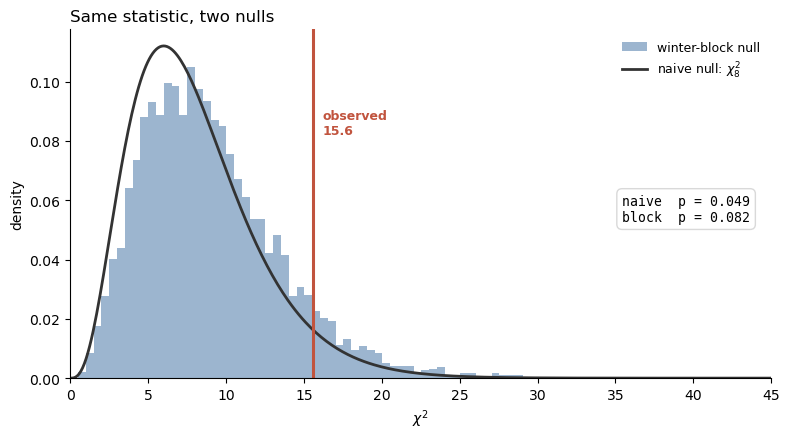

In [35]:
## Plotting the two nulls
fig, ax = plt.subplots(figsize=(8,4.5))
ax.hist(nb, bins=60, density=True, color='#4C78A8', alpha=.55, label='winter-block null')
xx = np.linspace(0,45,400)
ax.plot(xx, stats.chi2.pdf(xx, 8), color='#333333', lw=2, label=r'naive null: $\chi^2_8$')
ax.axvline(obs_chi2, color='#C1543E', lw=2.2)
ax.text(obs_chi2 + 0.6, ax.get_ylim()[1]*.7, f'observed\n{obs_chi2:.1f}',
        color='#C1543E', fontsize=9, fontweight='bold')

ax.text(.97, .45, f'naive  p = {p_naive:.3f}\nblock  p = {p_block:.3f}',
        transform=ax.transAxes, ha='right', fontsize=9.5, family='monospace',
        bbox=dict(fc='white', ec='0.85', boxstyle='round,pad=0.4'))

ax.set_xlim(0,45)
ax.set_xlabel(r'$\chi^2$')
ax.set_ylabel('density')
ax.set_title('Same statistic, two nulls', loc='left')
ax.legend(frameon=False, fontsize=9)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
fig.tight_layout()


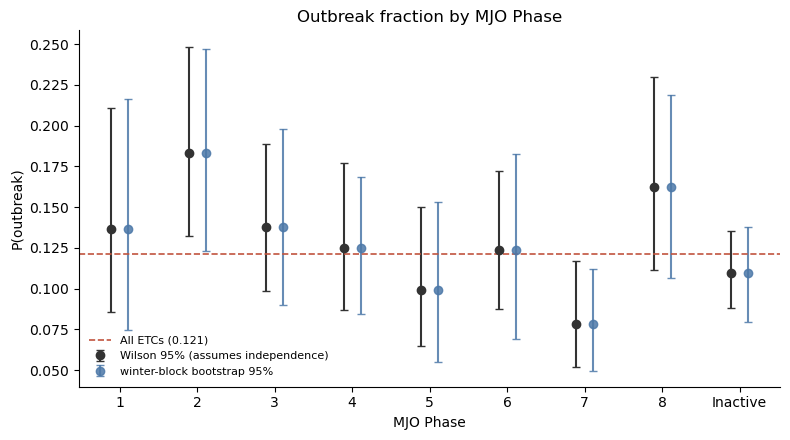

In [36]:
## Outbreak fraction
x = np.arange(len(t)) #mjo phases
fig, ax = plt.subplots(figsize=(8,4.5))
ax.errorbar(x - .11, t.outbreak_frac,
            yerr=[t.outbreak_frac - t.frac_lo, t.frac_hi - t.outbreak_frac],
            fmt='o', ms=6, color='#333333', capsize=3, lw=1.5,
            label='Wilson 95% (assumes independence)')
ax.errorbar(x + .11, t.outbreak_frac,
            yerr=[t.outbreak_frac - t.boot_lo, t.boot_hi - t.outbreak_frac],
            fmt='o', ms=6, color='#4C78A8', capsize=3, lw=1.5, alpha=.85,
            label='winter-block bootstrap 95%')
ax.axhline(base, color='#C1543E', ls='--', lw=1.2, label=f'All ETCs ({base:.3f})')
ax.set_xticks(x)
ax.set_xticklabels(CATS)
ax.set_xlabel('MJO Phase')
ax.set_ylabel('P(outbreak)')
ax.set_title('Outbreak fraction by MJO Phase')
ax.legend(frameon=False, fontsize=8)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
fig.tight_layout()

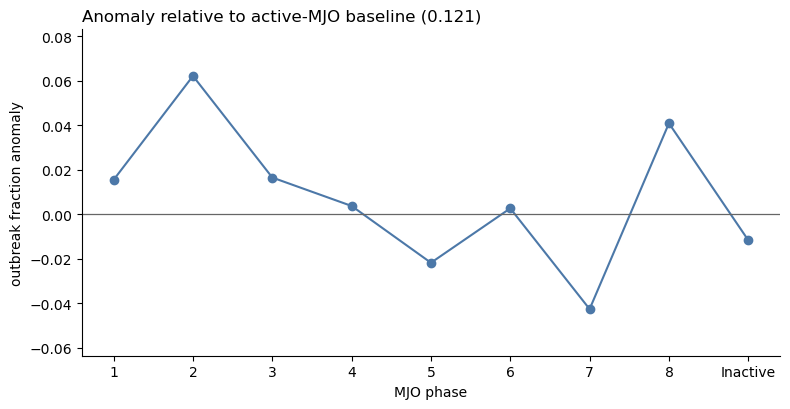

In [61]:
# --- the anomaly plot (their Fig 1b) ---
x = np.arange(9)
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(x, t.anomaly, 'o-', color='#4C78A8', ms=6, lw=1.5)
ax.axhline(0, color='0.4', lw=.9)
ax.set_xticks(x); ax.set_xticklabels(t.index)
ax.set_xlabel('MJO phase'); ax.set_ylabel('outbreak fraction anomaly')
ax.set_title(f'Anomaly relative to active-MJO baseline ({base:.3f})', loc='left')
ax.margins(y=.20)
for s in ('top','right'): ax.spines[s].set_visible(False)
fig.tight_layout()

In [ ]:
## building table t again but only for active phases of the MJO
PHASES = [str(i) for i in range(1,9)]
act = etc_summary[etc_summary.mjo != 'Inactive'].copy()

p0_active = act.outbreak.mean()

ta = (act.groupby('mjo', observed=False)['outbreak']
      .agg(n_etc='size', n_outbreak='sum')
      .reindex(PHASES))
ta['frac'] = ta.n_outbreak / ta.n_etc
ta['lo'], ta['hi'] = zip(*[wilson(k, n) for k, n in zip(ta.n_outbreak, ta.n_etc)])
ta['anomaly'] = ta.frac - p0_active


print(f'active ETCs: {len(act)} of {len(etc_summary)} ({len(act)/len(etc_summary):.0%})')
print(f'active-only baseline = {p0_active:.4f}   (all-ETC baseline = {etc_summary.outbreak.mean():.4f})')
print(ta.round(3))

active ETCs: 1559 of 2225 (70%)
active-only baseline = 0.1264   (all-ETC baseline = 0.1213)
     n_etc  n_outbreak   frac     lo     hi
mjo                                        
1      117          16  0.137  0.086  0.211
2      169          31  0.183  0.132  0.249
3      225          31  0.138  0.099  0.189
4      208          26  0.125  0.087  0.177
5      191          19  0.099  0.065  0.150
6      234          29  0.124  0.088  0.172
7      267          21  0.079  0.052  0.117
8      148          24  0.162  0.111  0.230


In [44]:
## Recalculating the winter block bootstrap but for only active phases
rng, B = np.random.default_rng(1), 3000
by_w = {w: d for w, d in act.groupby('winter')}
avail = np.sort(list(by_w.keys()))

boot = np.full((B, 8), np.nan)
for b in range(B):
    samp = pd.concat([by_w[w] for w in rng.choice(avail, len(avail), replace=True)])
    gg = (samp.groupby('mjo', observed=False)['outbreak']
          .agg(['size', 'sum'])
          .reindex(PHASES))
    boot[b] = np.where(gg['size'] > 0, gg['sum'] / gg['size'].replace(0, np.nan), np.nan)

ta['boot_lo'] = np.nanpercentile(boot,  2.5, axis=0)
ta['boot_hi'] = np.nanpercentile(boot, 97.5, axis=0)

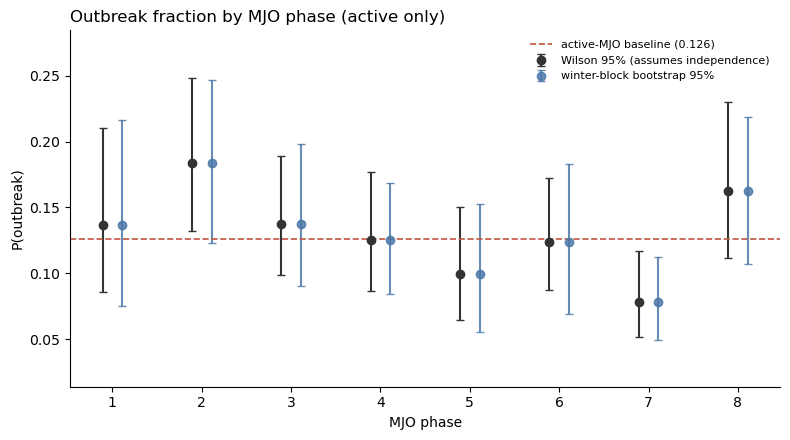

In [46]:
## Plot
x = np.arange(8)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(x - .11, ta.frac, yerr=[ta.frac - ta.lo, ta.hi - ta.frac],
            fmt='o', ms=6, color='#333333', capsize=3, lw=1.5,
            label='Wilson 95% (assumes independence)')
ax.errorbar(x + .11, ta.frac, yerr=[ta.frac - ta.boot_lo, ta.boot_hi - ta.frac],
            fmt='o', ms=6, color='#4C78A8', capsize=3, lw=1.5, alpha=.85,
            label='winter-block bootstrap 95%')
ax.axhline(p0_active, color='#C1543E', ls='--', lw=1.2,
           label=f'active-MJO baseline ({p0_active:.3f})')
ax.set_xticks(x); ax.set_xticklabels(PHASES)
ax.set_xlabel('MJO phase'); ax.set_ylabel('P(outbreak)')
ax.set_title('Outbreak fraction by MJO phase (active only)', loc='left')
ax.legend(frameon=False, fontsize=8); ax.margins(y=.18)
for s in ('top', 'right'): ax.spines[s].set_visible(False)
fig.tight_layout()

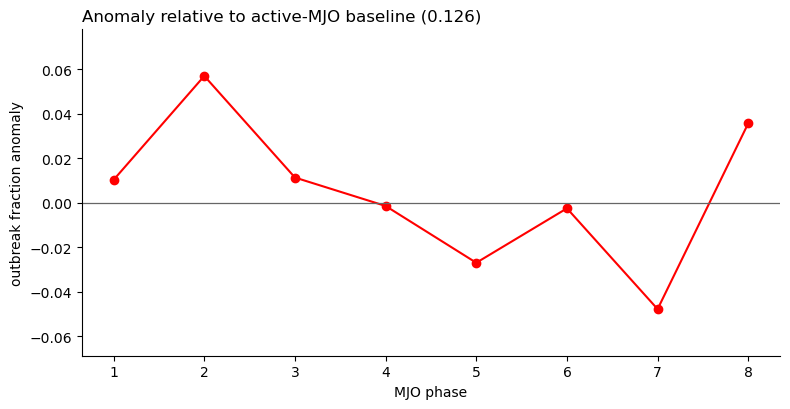

In [64]:
# the anomaly plot
x = np.arange(8)
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(x, ta.anomaly, 'o-', color='red', ms=6, lw=1.5)
ax.axhline(0, color='0.4', lw=.9)
ax.set_xticks(x); ax.set_xticklabels(ta.index)
ax.set_xlabel('MJO phase'); ax.set_ylabel('outbreak fraction anomaly')
ax.set_title(f'Anomaly relative to active-MJO baseline ({p0_active:.3f})', loc='left')
ax.margins(y=.20)
for s in ('top','right'): ax.spines[s].set_visible(False)
fig.tight_layout()

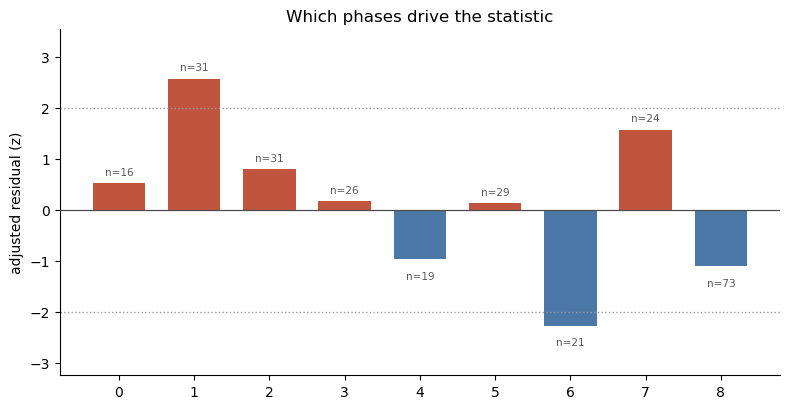

In [79]:
# Adjusted residuals
x = np.arange(len(t))
fig, ax = plt.subplots(figsize=(8,4.2))
ax.bar(x, t.resid_adj, width=0.7,
       color=['#C1543E' if v > 0 else '#4C78A8' for v in t.resid_adj])
for y in (-2, 2):
    ax.axhline(y, color='0.6', ls=':', lw=1)
ax.axhline(0, color='0.3', lw=0.9)
for xi, v, n in zip(x, t.resid_adj, t.n_outbreak):
    ax.annotate(f'n={n}', (xi,v), textcoords='offset points',
                xytext=(0, 6 if v > 0 else -14), ha='center', fontsize=7.5, color='0.35')
ax.set_xticks(x)
ax.set_ylabel('adjusted residual (z)')
ax.set_title('Which phases drive the statistic')
ax.margins(y=.20)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
fig.tight_layout()


In [ ]:
## outbreaks per winter and category
pv = (etc_summary[etc_summary.outbreak]
      .pivot_table(index='winter', columns='mjo', values='outbreak',
                   aggfunc='sum', observed=False)
       .reindex(columns=CATS).fillna(0))


In [93]:
pv

mjo,1,2,3,4,5,6,7,8,Inactive
winter,,,,,,,,,
1996,1,2,1,1,0,0,2,0,1
1997,3,0,0,0,2,5,0,2,2
1998,0,3,2,0,0,0,1,1,5
1999,0,4,3,0,1,1,1,1,0
2000,0,0,2,3,0,0,0,0,5
2001,0,1,1,0,1,0,1,0,3
2002,0,0,2,2,0,0,1,0,1
2003,1,2,1,0,0,0,0,0,2
2004,0,0,0,1,0,1,0,1,0


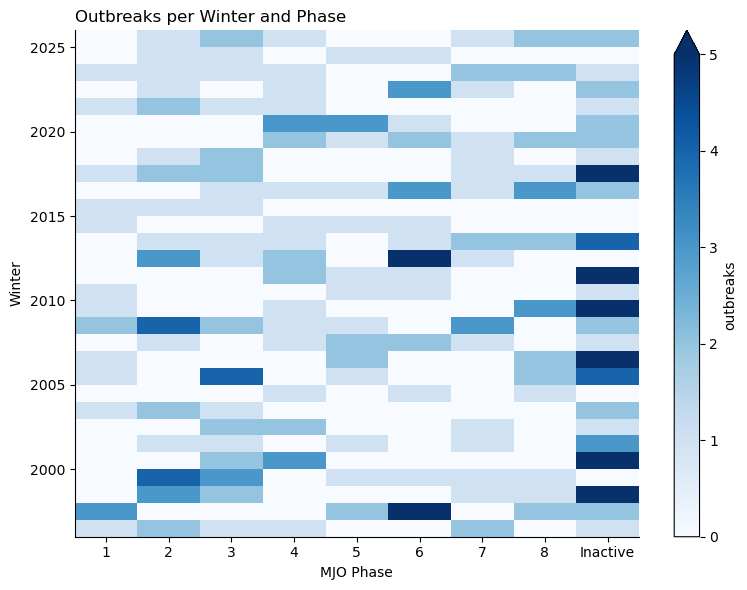

In [83]:
fig, ax = plt.subplots(figsize=(8,6))
m = ax.pcolormesh(np.arange(len(CATS) + 1), np.append(pv.index, pv.index[-1] + 1),
                  pv.values, cmap='Blues', shading='flat', vmin=0, vmax=5)
ax.set_xticks(np.arange(len(CATS)) + 0.5)
ax.set_xticklabels(CATS)
ax.set_xlabel('MJO Phase')
ax.set_ylabel('Winter')
ax.set_title('Outbreaks per Winter and Phase', loc='left')
fig.colorbar(m, ax=ax, label='outbreaks', extend='max')

for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
fig.tight_layout()

#### Testing if I combine the phases into two groups (1-4, 5-8), since Tippett (2018) found sig. differences between the two

In [10]:
mjo

,year,month,day,RMM1,RMM2,phase,amplitude,method,time,winter,dow,MJO
0,1974,6,1,1.634470,1.203040,5.0,2.029480,WH04_method:_OLR_&_NCEP_wind,1974-06-01,1974,182,5.0
1,1974,6,2,1.602890,1.015120,5.0,1.897290,WH04_method:_OLR_&_NCEP_wind,1974-06-02,1974,183,5.0
2,1974,6,3,1.516250,1.085510,5.0,1.864760,WH04_method:_OLR_&_NCEP_wind,1974-06-03,1974,184,5.0
3,1974,6,4,1.509810,1.035730,5.0,1.830920,WH04_method:_OLR_&_NCEP_wind,1974-06-04,1974,185,5.0
4,1974,6,5,1.559060,1.305180,5.0,2.033260,WH04_method:_OLR_&_NCEP_wind,1974-06-05,1974,186,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
19078,2026,8,25,-0.200126,0.698792,7.0,0.726884,Gottschalk10_method:_OLR_&_ACCESS_wind,2026-08-25,2026,267,<NA>
19079,2026,8,26,-0.432785,0.825932,7.0,0.932451,Gottschalk10_method:_OLR_&_ACCESS_wind,2026-08-26,2026,268,<NA>
19080,2026,8,27,-0.454163,1.161678,7.0,1.247300,Gottschalk10_method:_OLR_&_ACCESS_wind,2026-08-27,2026,269,7.0
19081,2026,8,28,-0.361866,0.992215,7.0,1.056143,Gottschalk10_method:_OLR_&_ACCESS_wind,2026-08-28,2026,270,7.0


In [20]:
mjo_daily = mjo.loc[mjo.time.dt.month.isin([12,1,2,3]), ['time', 'mjo']].copy()

In [21]:
def to_group(phase):
    p = pd.to_numeric(phase, errors='coerce')
    return pd.Categorical(np.where(p.isna(), None,
                                   np.where(p <= 4, 'P1=4', 'P5-8')),
                                   categories=['P1-4', 'P5-8'])

In [22]:
mjo_daily

,time,mjo
183,1974-12-01,7
184,1974-12-02,7
185,1974-12-03,8
186,1974-12-04,Inactive
187,1974-12-05,Inactive
...,...,...
18927,2026-03-27,Inactive
18928,2026-03-28,Inactive
18929,2026-03-29,8
18930,2026-03-30,1


In [30]:
mjo_daily['grp'] = to_group(mjo_daily.mjo)
etc_summary['grp'] = to_group(etc_summary.MJO_min_msl)

In [35]:
mjo_daily['grp']


183      P5-8
184      P5-8
185      P5-8
186       NaN
187       NaN
         ... 
18927     NaN
18928     NaN
18929    P5-8
18930     NaN
18931     NaN
Name: grp, Length: 6305, dtype: category
Categories (2, object): ['P1-4', 'P5-8']

In [28]:
e = etc_summary[etc_summary.grp.notna()].copy()

g = e.groupby('grp', observed=False)['outbreak']
tab = pd.DataFrame({'n_etc': g.size(), 'n_outbreak': g.sum()})
tab['frac'] = tab.n_outbreak / tab.n_etc
tab['lo'], tab['hi'] = zip(*[wilson(k,n) for k, n in zip(tab.n_outbreak, tab.n_etc)])
print(tab.round(4))
print(f'\nETCs retained: {len(e)} of {len(etc_summary)} '
      f'({len(e)/len(etc_summary):.0%}); inactive excluded')

      n_etc  n_outbreak    frac      lo      hi
grp                                            
P1-4      0           0     NaN     NaN     NaN
P5-8    840          93  0.1107  0.0912  0.1337

ETCs retained: 840 of 2225 (38%); inactive excluded


In [ ]:
p58, p14 = tab.loc['P5-8', 'frac'], tab.loc['P1-4', 'frac']
obs_diff = p58 - p14
odds = (tab.loc['P5-8','n_outbreak'] / (tab.loc['P5-8','n_etc'] - tab.loc['P5-8','n_outbreak'])) / \
       (tab.loc['P1-4','n_outbreak'] / (tab.loc['P1-4','n_etc'] - tab.loc['P1-4','n_outbreak']))
print(f'\nrisk difference (5-8 minus 1-4) = {obs_diff:+.4f}')
print(f'risk ratio  = {p58/p14:.3f}')
print(f'odds ratio  = {odds:.3f}')

### ENSO Modulation